# Validation Thresholds

The validation thresholds for [Qwen/Qwen3-VL-235B-A22B-Instruct-FP8](https://huggingface.co/Qwen/Qwen3-VL-235B-A22B-Instruct-FP8) were computed following the standard validation threshold computation methodology. Full details of this process are documented in [`proposals/visual_models/README-new.md`](../../../../proposals/visual_models/README-new.md).

In this notebook a scenario where a fraudster plans to pass off [7-B Visual model](https://huggingface.co/Qwen/Qwen2.5-VL-7B-Instruct) as [235-B Visual model](https://huggingface.co/Qwen/Qwen3-VL-235B-A22B-Instruct-FP8) is considered.

This notebook suggest an analysis part given the precomputed raw data from inference-validation cycles. You can reproduce this analysis here. 
 
If you want to reproduce the full procedure, including the inference-validation cycles, you'll need to refer to the [`proposals/visual_models/README-new.md`](../../../../proposals/visual_models/README-new.md) and learn there how to conduct the inference part.

The `vlm_inference.py` that produced the raw data for this analysis can be found [here](../scripts/inference_validation/vlm_inference.py) 

## Overview

Key results of this experiments are:
- **Validation threshold lower bound**: `0.0214`
- **Fraud Detection Rate**: **100%**

These thresholds ensure robust fraud detection while accommodating legitimate hardware-induced variations in probability distributions.

All inference-validation cycle results, including full JSONL datasets and configuration files, are available in the shared Google Drive folder [link](https://drive.google.com/file/d/1Vl_HQhgb2LVeZf9-m8EEsaAlJBk-Fv33/view?usp=share_link), which includes
- Complete inference-validation JSONL files (~20-70MB per configuration)
- Configuration JSON files for each run.  

IMPORTANT: if you want the code below to work, you'll need to download the files and define the path to this files below.


Below is the analysis code for the resulting raw data from inference-validation cycles.

To be able to analyse the results yourself, you need:
1. Download the raw data and configs
2. Put all the files, including raw data and configs to one place
3. Set `GONKA_PATH` (env var pointing to the gonka repo root; auto-detected when run from `notebooks/`) and `data_path` (path to the folder containining downloaded data) correctly to be able to import the code and files.
4. Run the code cells

## Data preparation

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

gonka_path = os.environ.get(
    "GONKA_PATH",
    str((Path.cwd() / "../../../..").resolve()),
)

sys.path.append(os.path.join(gonka_path, 'mlnode/packages/benchmarks/src'))
sys.path.append(os.path.join(gonka_path, 'mlnode/packages/common/src'))
import copy
import numpy as np

from validation.data import load_from_jsonl

from validation.analysis import find_optimal_bounds_parallel, evaluate_bound, classify_data
from validation.analysis import analyze, process_data, plot_classification_results, plot_length_vs_distance_comparison

### Test Configurations


**Fraudulent Inference Scenarios** test fraud detection capability when inference uses a smaller model ([Qwen/Qwen2.5-VL-7B-Instruct](https://huggingface.co/Qwen/Qwen2.5-VL-7B-Instruct)). 
1. **4xA100 (FP8) vs 1xA100 (FP16, small), the same hardware**: Primary fraud detection test


Below you'll see how each test scenarios' raw file is loaded.

In [2]:
model_name = 'qwen3-235B-VL'

##### This part should be changed according to the path where json files are generated or downloaded #######
data_path = os.path.join(gonka_path, 'mlnode/packages/benchmarks/data/235b-inference_results-new/validation')
fraud_data_path = os.path.join(gonka_path, 'mlnode/packages/benchmarks/data/7b-inference_results/validation')

honest_data_paths = [
    os.path.join(data_path, 'fp8-enf_h100-h100/validation_results.jsonl'),
]

fraud_data_paths = [
    os.path.join(fraud_data_path, 'validation_results.jsonl'),
]
##############################################################################################################

DATA_PATHS = {
    "honest_qwen3_235b_vl-h100-vs-h100": honest_data_paths[0],
    "fraud_qwen2.5_7b_vl-a100-vs-qwen3_235b_vl-a100": fraud_data_paths[0],
}   

Below are some preparation steps: get the distances and items from the raw data

In [3]:
honest_items_dict, honest_distances_dict = {}, {}
fraud_items_dict, fraud_distances_dict = {}, {}
honest_distances, fraud_distances = [], []
honest_point_hue, fraud_point_hue = [], []

for name, path in DATA_PATHS.items():
    items, distances, topk = process_data(load_from_jsonl(path, n=1000), topk=5)
    if 'honest' in name:
        honest_items_dict[name] = items
        honest_distances_dict[name] = distances
        honest_distances.extend(distances)
        honest_point_hue.extend([name] * len(distances))
    if 'fraud' in name:
        fraud_items_dict[name] = items
        fraud_distances_dict[name] = distances
        fraud_distances.extend(distances)
        fraud_point_hue.extend([name] * len(distances))

Dropped 0 / 1000 items
Dropped 0 / 1000 items


## Finding the optimal thresholds

The resulting threshold is set up to bring False Positive Rate to zero and minimize F1-score.

The threshold is computed based on all the computed honest and fraud inference-validation scenarios.

In [4]:
optimal_lower, _ = find_optimal_bounds_parallel(honest_distances, fraud_distances, n_jobs=64, step=0.001)

Searching optimal bounds:   0%|          | 0/201 [00:00<?, ?it/s]

Searching optimal bounds: 100%|██████████| 201/201 [00:02<00:00, 69.09it/s]


Optimal Lower Bound: 0.021382
Best F1-Score: 1.0000


## Distances Distribution Analysis

In [6]:
print(f"Threshold: {optimal_lower:.4f}")

classifications_honest = classify_data(honest_distances, optimal_lower, _)
classifications_fraud = classify_data(fraud_distances, optimal_lower, _)

Threshold: 0.0214


#### Honest Classification

This plot shows the distribution of validation distances for legitimate (honest) inferences using the correct FP8 model on both sides.

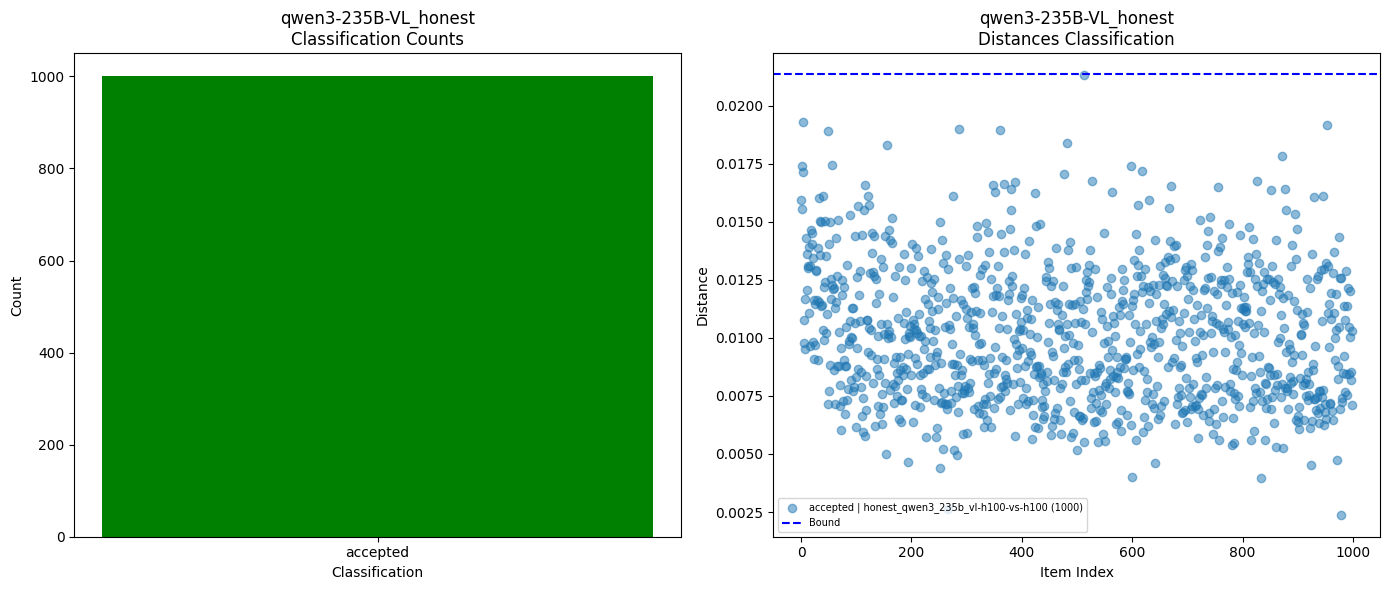

In [7]:
plot_classification_results(
    honest_distances,
    classifications_honest,
    optimal_lower, _,
    title_prefix=f"{model_name}_honest",
    point_hue=honest_point_hue,
    # save_to='../data/graphs'
)

#### Fraud Classification

This plot illustrates how fraudulent inferences produce significantly higher validation distances. The threshold bounds separate a substantial portion of fraud cases from honest behavior, with 100% of fraud samples falling in the "fraud" classification zone.

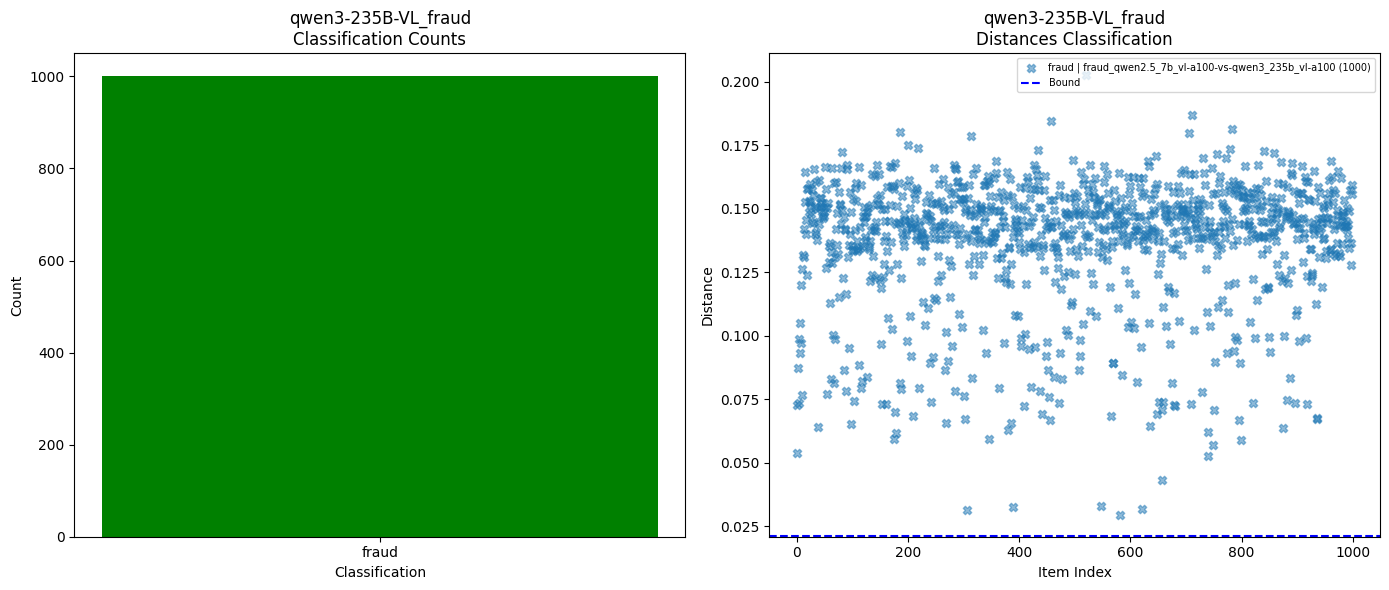

In [8]:
plot_classification_results(
    fraud_distances,
    classifications_fraud,
    optimal_lower,
    _,
    title_prefix=f"{model_name}_fraud",
    point_hue=fraud_point_hue,
    # save_to='../data/graphs'
)

#### Length vs Distance Comparison

This scatter plot examines the relationship between response length and validation distance across different configurations with different inference request languages. It is a birdview graph to understand the distance distributions.

- **Blue and red/orange points**: honest and fraud inferences
- **Marker shapes**: language of inference request
- **Horizontal lines**: lower and upper threshold bounds

Share of fraud found = 1.0


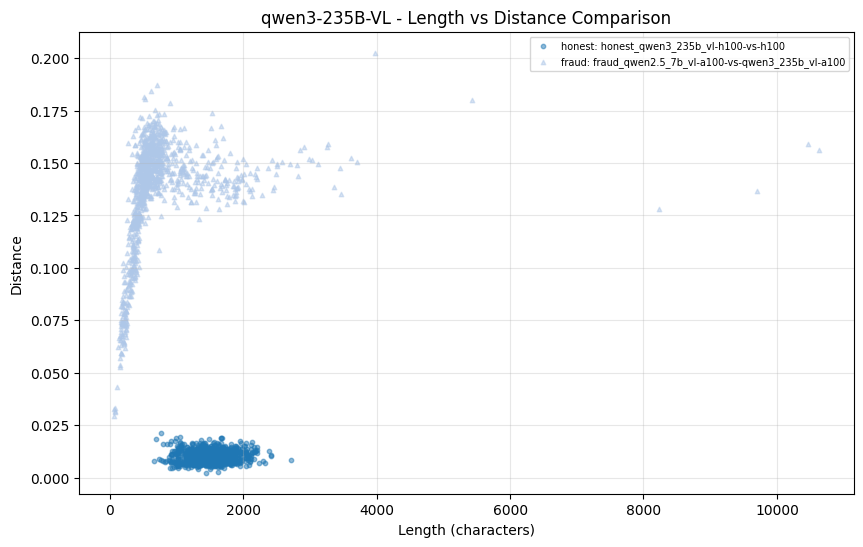

In [9]:
print('Share of fraud found =', sum(np.array(classifications_fraud) == 'fraud')/len(classifications_fraud))
plot_length_vs_distance_comparison(
    model_name,
    honest_items_dict,
    honest_distances_dict,
    fraud_items_dict,
    fraud_distances_dict,
    hue_by_series=True,
    # save_to='../data/graphs'
)


#### Conclusion

The inference results of [Qwen/Qwen3-VL-235B-A22B-Instruct-FP8](https://huggingface.co/Qwen/Qwen3-VL-235B-A22B-Instruct-FP8) can be separated from the results of [7-B Visual model](https://huggingface.co/Qwen/Qwen2.5-VL-7B-Instruct) with enough precision to be confident that the Gonka network will be safe from the fraud using this model.